In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler,RobustScaler
from imblearn.over_sampling import SMOTE
df=pd.read_csv('diabetes.csv')

print(display(df.describe()))
# df["BMI_Age"] = df["BMI"] * df["Age"]
# df["Glucose_BMI"] = df["Glucose"] * df["BMI"]
# df["Insulin_Glucose"] = df["Insulin"] / (df["Glucose"] + 1)
# df["Age_Pregnancies"] = df["Age"] * df["Pregnancies"]

# print(len(df))
# print(df.describe())
# print(df.info())
x_df=df.drop(['Outcome'],axis=1)
y_df=df['Outcome']
features=x_df.columns




,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


None


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13068\3425672894.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


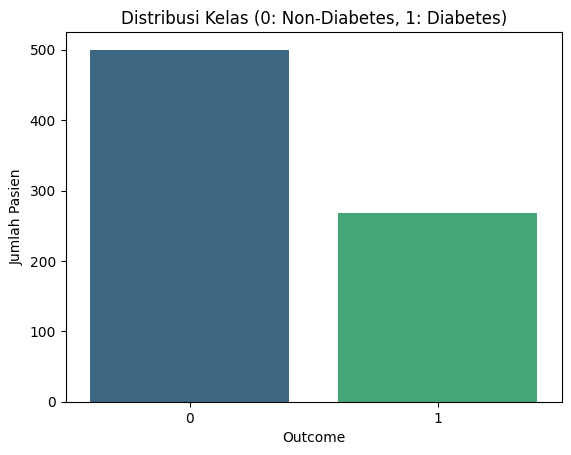

In [32]:
sns.countplot(x='Outcome', data=df, palette='viridis')

# Memberikan judul dan label
plt.title('Distribusi Kelas (0: Non-Diabetes, 1: Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Pasien')

plt.show()

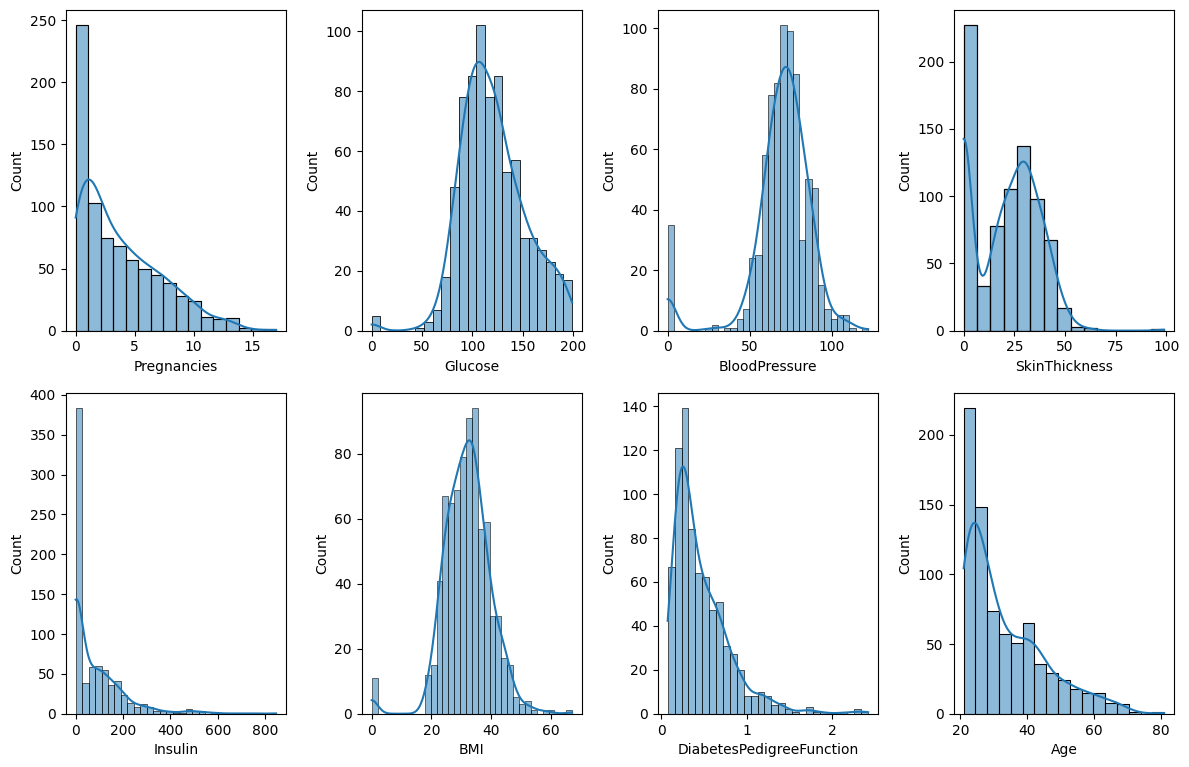

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [33]:
plt.figure(figsize=(12,15))

for i,col in enumerate(features):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True)

plt.tight_layout()
plt.show()
df.describe()

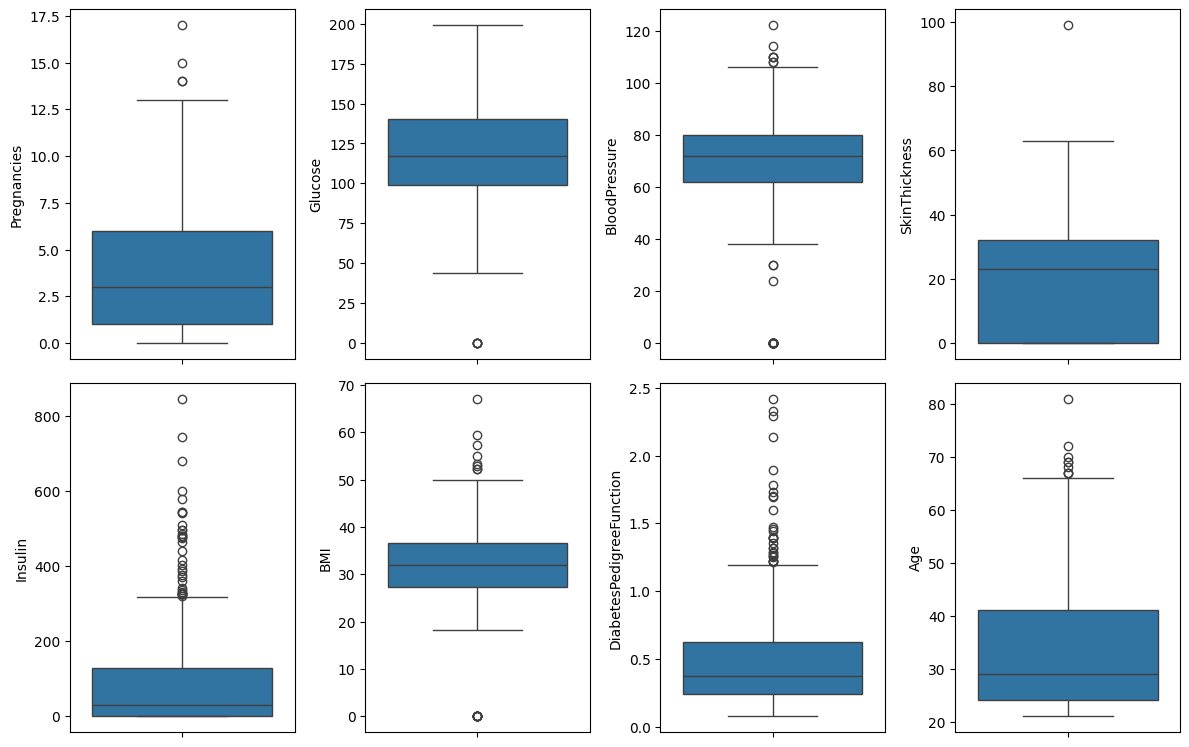

In [34]:
plt.figure(figsize=(12,15))
for i,col in enumerate(features):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
plt.tight_layout()
plt.show()

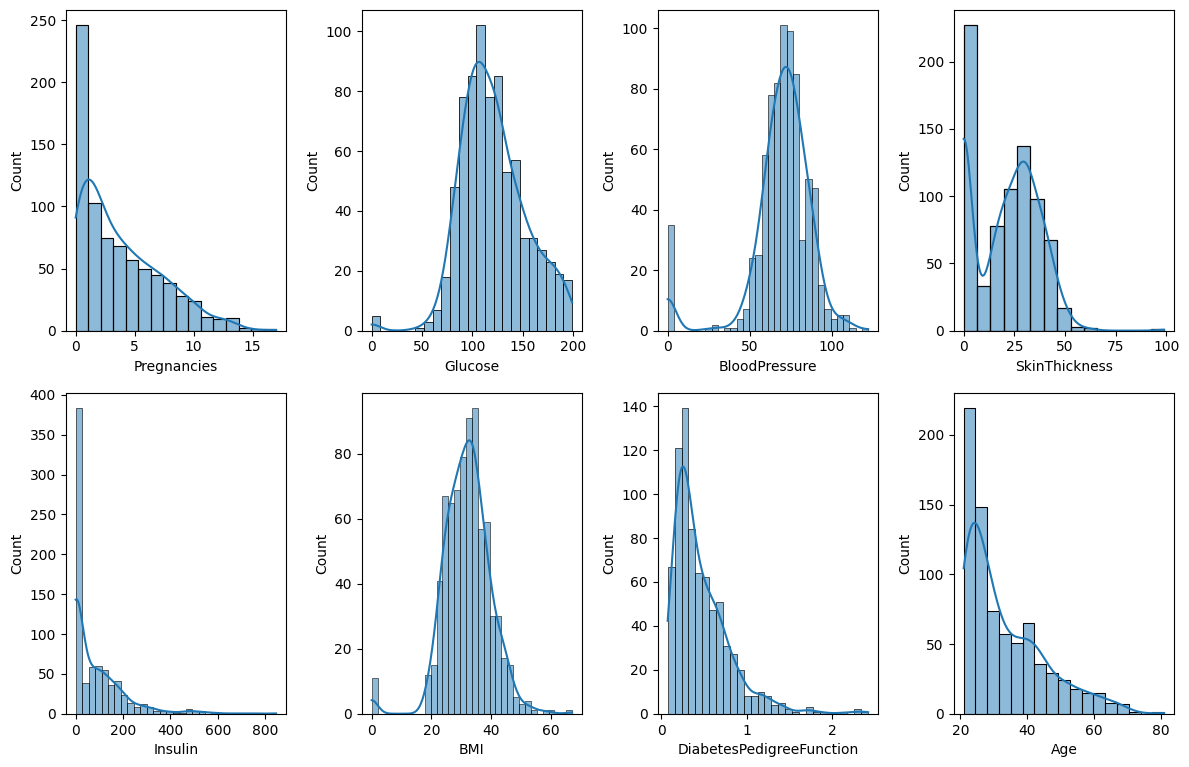

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [35]:
plt.figure(figsize=(12,15))
for i,col in enumerate(features):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True)

plt.tight_layout()
plt.show()
df.describe()

In [36]:
x_df=df.drop('Outcome', axis=1)
y_df=df['Outcome']
scalar=StandardScaler()
cols_with_zeros=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
x_df[cols_with_zeros]=x_df[cols_with_zeros].replace(0, np.nan)
# x_df[cols_with_zeros]=x_df[cols_with_zeros].fillna(x_df[cols_with_zeros].median())
# x_df=scalar.fit_transform(x_df)
x_train,x_test,y_train,y_test=train_test_split(x_df,y_df,test_size=0.3,random_state=42,stratify=y_df)
median_data=x_train[cols_with_zeros].median()

x_train[cols_with_zeros]=x_train[cols_with_zeros].fillna(median_data)

x_test[cols_with_zeros]=x_test[cols_with_zeros].fillna(median_data)
# x_train["BMI_Age"] = x_train["BMI"] * x_train["Age"]
# x_train["Glucose_BMI"] = x_train["Glucose"] * x_train["BMI"]
# x_train["Insulin_Glucose"] = x_train["Insulin"] / (x_train["Glucose"] + 1)
# x_train["Age_Pregnancies"] = x_train["Age"] * x_train["Pregnancies"]
# x_test["BMI_Age"] = x_test["BMI"] * x_test["Age"]
# x_test["Glucose_BMI"] = x_test["Glucose"] * x_test["BMI"]
# x_test["Insulin_Glucose"] = x_test["Insulin"] / (x_test["Glucose"] + 1)
# x_test["Age_Pregnancies"] = x_test["Age"] * x_test["Pregnancies"]


# outliers=['BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Pregnancies']
# for col in outliers:
#     Q1 = x_train[col].quantile(0.25)
#     Q3 = x_train[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     x_train[col] = x_train[col].clip(lower=lower, upper=upper)
#     x_test[col] = x_test[col].clip(lower=lower, upper=upper)


                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                    1.0000   0.1510         0.1998         0.1247   
Glucose                        0.1510   1.0000         0.2093         0.1923   
BloodPressure                  0.1998   0.2093         1.0000         0.1867   
SkinThickness                  0.1247   0.1923         0.1867         1.0000   
Insulin                        0.0843   0.4517         0.0746         0.2382   
BMI                            0.0139   0.1969         0.2528         0.5462   
DiabetesPedigreeFunction      -0.0530   0.1155        -0.0273         0.0961   
Age                            0.5260   0.2910         0.3054         0.1268   

                          Insulin     BMI  DiabetesPedigreeFunction     Age  
Pregnancies                0.0843  0.0139                   -0.0530  0.5260  
Glucose                    0.4517  0.1969                    0.1155  0.2910  
BloodPressure              0.0746  0.2528    

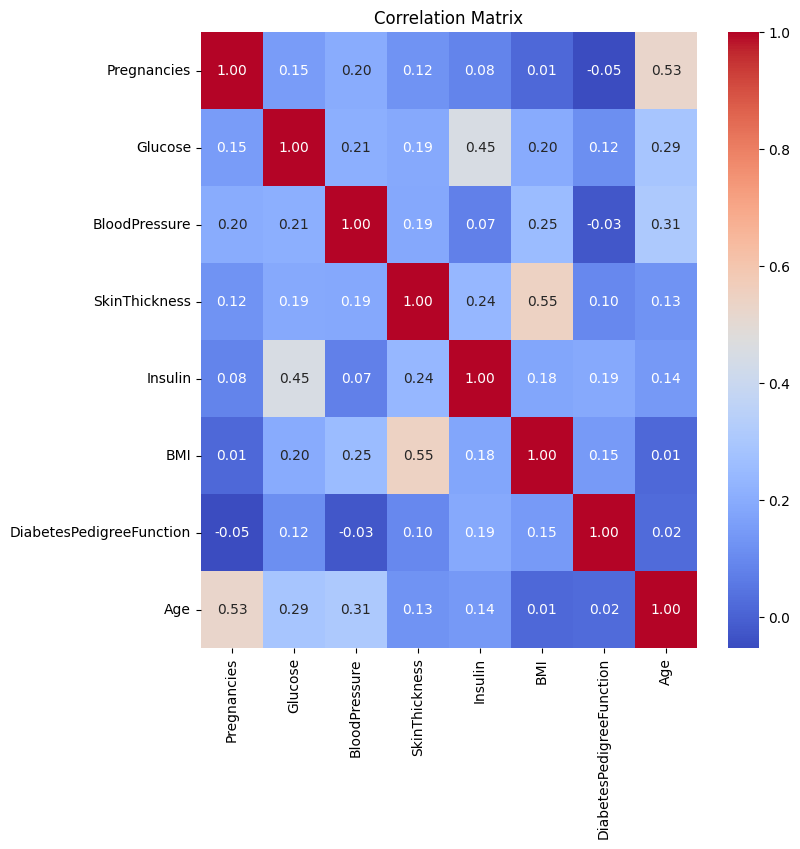

In [37]:
num_cols=x_train.select_dtypes(include=np.number).columns.tolist()
corr_matrix=round(x_train[num_cols].corr(numeric_only=True),4)
print(corr_matrix)

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [38]:
num_cols=df.select_dtypes(include=np.number).columns.tolist()
corr_matrix=round(df[num_cols].corr(numeric_only=True),4)
print(corr_matrix)

                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                    1.0000   0.1295         0.1413        -0.0817   
Glucose                        0.1295   1.0000         0.1526         0.0573   
BloodPressure                  0.1413   0.1526         1.0000         0.2074   
SkinThickness                 -0.0817   0.0573         0.2074         1.0000   
Insulin                       -0.0735   0.3314         0.0889         0.4368   
BMI                            0.0177   0.2211         0.2818         0.3926   
DiabetesPedigreeFunction      -0.0335   0.1373         0.0413         0.1839   
Age                            0.5443   0.2635         0.2395        -0.1140   
Outcome                        0.2219   0.4666         0.0651         0.0748   

                          Insulin     BMI  DiabetesPedigreeFunction     Age  \
Pregnancies               -0.0735  0.0177                   -0.0335  0.5443   
Glucose                    0.3314  0.2211

In [39]:

x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)
# smote = SMOTE(random_state=42)
# x_train, y_train = smote.fit_resample(x_train, y_train)

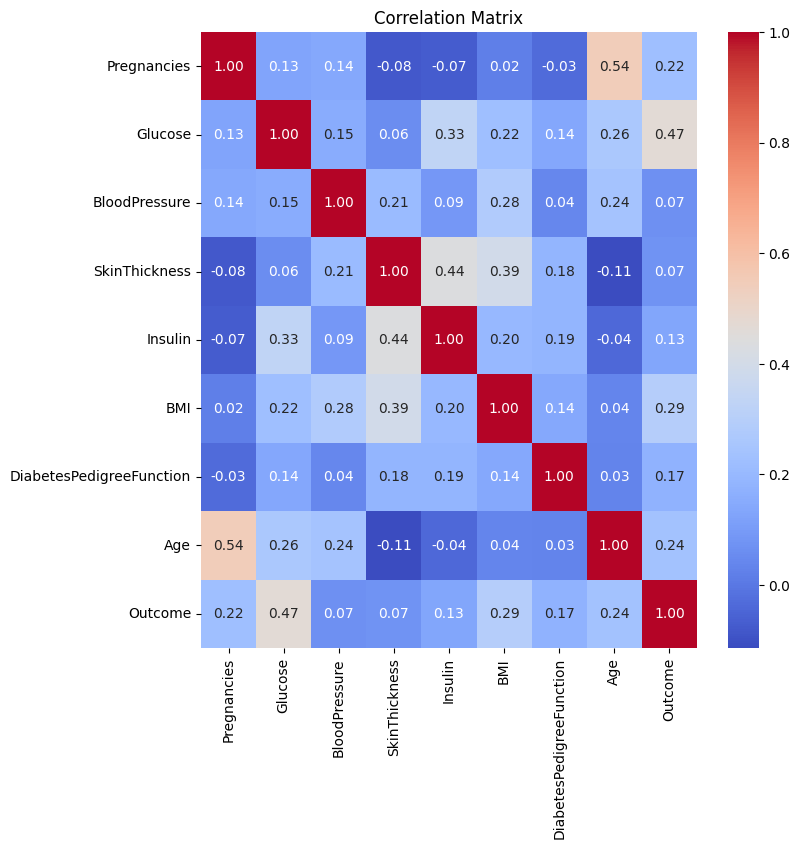

In [40]:


plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [41]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score,recall_score,precision_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
param_grid_lg = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000,class_weight="balanced"),
    param_grid_lg,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)


param_grid_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42,class_weight='balanced'),
    param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)




grid_lr.fit(x_train, y_train)

best_lr_model = grid_lr.best_estimator_
best_rf_model = grid_rf.best_estimator_
print(best_lr_model)
print(best_rf_model)
y_pred_lr = best_lr_model.predict(x_test)

y_pred_rf = best_rf_model.predict(x_test)


ensemble_model = VotingClassifier(
    estimators=[('lr', best_lr_model), ('rf', best_rf_model)],
    voting='soft'
)

ensemble_model.fit(x_train, y_train)







LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')
RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)


,estimators,"[('lr', ...), ('rf', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l1'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True


In [42]:


y_prob=ensemble_model.predict_proba(x_test)[:,1]
y_pred=(y_prob>0.35).astype(int)
print(f'Ensemble method (F1 Score): {(f1_score(y_test, y_pred) * 100):.2f}%')
print(f'Ensemble method (Accuracy Score): {(accuracy_score(y_test, y_pred) * 100):.2f}%')
print(f'Ensemble method (Recall Score): {(recall_score(y_test, y_pred) * 100):.2f}%')
print(f'Ensemble method (Precision Score): {(precision_score(y_test, y_pred) * 100):.2f}%')



Ensemble method (F1 Score): 71.22%
Ensemble method (Accuracy Score): 74.46%
Ensemble method (Recall Score): 90.12%
Ensemble method (Precision Score): 58.87%


In [43]:
y_prob = best_lr_model.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)

print(f'Logistic Regression (F1 Score): {(f1_score(y_test, y_pred) * 100):.2f}%')
print(f'Logistic Regression (Accuracy Score): {(accuracy_score(y_test, y_pred) * 100):.2f}%')
print(f'Logistic Regression (Recall Score): {(recall_score(y_test, y_pred) * 100):.2f}%')
print(f'Logistic Regression (Precision Score): {(precision_score(y_test, y_pred) * 100):.2f}%')

Logistic Regression (F1 Score): 69.61%
Logistic Regression (Accuracy Score): 73.16%
Logistic Regression (Recall Score): 87.65%
Logistic Regression (Precision Score): 57.72%


In [44]:
y_prob = best_rf_model.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)

print(f'Random Forest (F1 Score): {(f1_score(y_test, y_pred) * 100):.2f}%')
print(f'Random Forest (Accuracy Score): {(accuracy_score(y_test, y_pred) * 100):.2f}%')
print(f'Random Forest (Recall Score): {(recall_score(y_test, y_pred) * 100):.2f}%')
print(f'Random Forest (Precision Score): {(precision_score(y_test, y_pred) * 100):.2f}%')

Random Forest (F1 Score): 70.94%
Random Forest (Accuracy Score): 74.46%
Random Forest (Recall Score): 88.89%
Random Forest (Precision Score): 59.02%


In [45]:

import joblib
model_package = {
    'model': ensemble_model,
    'scaler': scalar,
    'train_medians': median_data,
    'cols_with_zeros': cols_with_zeros,
    'threshold': 0.35,
    'feature_names': list(x_df.columns)
}


joblib.dump(model_package, 'diabetes_model.joblib')



['diabetes_model.joblib']